In [53]:
%%bash
pip install scikit-learn

mkdir storm_mode
cd storm_mode
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_train_data.csv
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_test_data.csv

mkdir: cannot create directory ‘storm_mode’: File exists


# Chapter 8.4 - Random Forest

In Chapter 8.3, we introduced the supervised machine learning classifier called a [decision tree](https://en.wikipedia.org/wiki/Decision_tree_learning). We went through the calculations used to decide split and classification decisions. However, one major limitation of the decision tree is that it is a [greedy algorithm](https://en.wikipedia.org/wiki/Greedy_algorithm). In other words, when the model is making a split decision, that decision is *only* based on minimizing error in the two resulting subsets (i.e., "local" error minimized). It is possible that a less-ideal split decision at first could lead to a better overall model performance (i.e., "global" error minimized).

**Storm Chasing Decision**

<img src="https://upload.wikimedia.org/wikipedia/commons/8/8c/Pilger%2C_NE_tornadoes.jpg" width=1000>

Consider a situation where you are storm chasing and trying to pick the best supercell towards which to drive your car. Imagine that you are going to use a database of your chasing success / failures to make your decision. One factor might be `distance_to_storm`, which is how far you are from the ideal viewing location of a storm. Another factor might be `storm_environment`, which is how supportive the atmosphere is for tornado development around a storm.

You notice that the best decision the majority of the time is to pick the storm closest to you. If you then train your dataset with a decision tree, it might tell you to chase the closest storm! However, when examining the dataset more closely, you notice that the 2nd best choice is `storm_environment`. In a situation where storm A is 1 mile closer than storm B, but storm B has the better environment, you might instead choose to drive to storm B. This is an example of an interaction between two variables--namely, the influence of `distance_to_storm` on a chasing decision depends on the `storm_environment`. This generalization might be obvious to those who storm chase, but it is a big motivating factor for using more complex machine learning models: *being farther away from a storm hurts less when the farther storm has a good environment*.

**Activity: Consider the situation below, where your car is for some reason dangerously close to the hook echo of a tornadic supercell. What cell would you pick? What is your rationale? Do *not* share your opinions with anyone yet, but keep track of your opinion.**

<img src="https://nimbus.niu.edu/courses/EAE483/car_chase.png" width=1000></img>

Now, consider a situation where you have 4 people in the car who always storm chase with eachother and no one else. You randomly assign a subset of storm chase results and factors for each person to examine. Each case could be examined by 1 - 4 people. You then have everyone train a decision tree on their subset and report back with their vote on what storm to chase. To your surpise, you notice that not everyone has the same vote! This is an example of [bootstrapping](https://en.wikipedia.org/wiki/Bootstrapping_(statistics))--the process of randomly sampling a dataset (with replacement) and estimating how this modifies the aggregate performance and variability of a decision-making model.

**Activity: Take the online survey provided by the instructor.**

<img src=https://nimbus.niu.edu/courses/EAE483/syc_tor.gif width=1000>

### Chapter 8.4.1 - Decision Tree vs. Random Forest

A *Random Forest* model is comprised of dozens (or thousands) of Decision Trees that each provide a "vote" that gets counted towards the final prediction. If every tree had the same configuration, saw the same data, and calculated split decisions in the same way, these votes (i.e., [ensemble prediction](https://en.wikipedia.org/wiki/Ensemble_learning)) would have very little diversity. The resulting tree ensemble "vote" would not perform much better than a prediction from a single Decision Tree. The strength of the Random Forest approach is that, ideally, an ensemble of Decision Trees trained in slightly different ways on slightly different training data will reduce the high prediction variance of a single Decision Tree. For example, one tree may make a poor splitting decision, while another tree may avoid that split decision because it was trained on different sample data or a different subset of features.

**Bagging**

Random Forest uses bootstrap aggregating ([bagging](https://en.wikipedia.org/wiki/Bootstrap_aggregating)) to generate an ensemble of slightly different decision trees that: 1) see a smaller sample of the dataset (with replacement); 2) a smaller subset of features ([feature bagging](https://en.wikipedia.org/wiki/Random_subspace_method); with replacement); and 3) aggregates the predictions of the "weak learners" (i.e., Decision Tree) into a final prediction.

1. **Bootstrapping** - Each decision tree in the ensemble is "shown" a sample of the dataset (with replacement) and are only allowed to use a random subset of features.

2. **Aggregating** - The majority of predictions (categorical) or the mean of the predictions (regression) are used to generate the final prediction.

The following example shows the bagging process, where the original dataset (top circles) get sampled for each "weak" learner (boostrapping). The predictions from each learner are aggregated for the final prediction.

<img src="https://upload.wikimedia.org/wikipedia/commons/c/c8/Ensemble_Bagging.svg" width=1000>

### Chapter 8.4.2 - Random Forest vs. Weather Model Ensembles

The GEFS ([Global Ensemble Forecasting System](https://www.ncei.noaa.gov/products/weather-climate-models/global-ensemble-forecast) creates ensemble forecasts by providing slightly different initial conditions within an envelope of observational uncertainty. This is somewhat similar to how Random Forest uses `bootstrapping` to show different ensemble members different data. For example, here are the individual ensemble predictions from the [CoD website](https://weather.cod.edu) for the [supercell composite parameter](https://ams.confex.com/ams/pdfpapers/46942.pdf):

<img src=https://nimbus.niu.edu/courses/EAE483/cod_gefs_example.png width=1000>

Each ensemble member produces slightly different solutions due to model deficiencies, uncertainty in initial conditions, and [the chaotic nature of the atmosphere](https://en.wikipedia.org/wiki/Chaos_theory). When you then calculate the ensemble mean, you are `aggregating` those predictions. This mean captures the central tendency / signal in the ensemble members and may provide a more realistic prediction. So in a way, you may have already extensively used a product analogous to `bagging`.

**Activity**: Assess the mean prediction below. Do you think that it is indicative of the actual risk? What are some characteristics of the ensemble members that might introduce bias into the mean?

<img src=https://nimbus.niu.edu/courses/EAE483/mean_ensemble_gefs_cod.png width=1000>

**Activity**: Assess the deterministic prediction from GFS ([Global Forecast System](https://www.ncei.noaa.gov/products/weather-climate-models/global-forecast)) for the same time period. What is your interpretation of the strength of this prediction? What would you tell someone about the potential for severe weather?

<img src=https://nimbus.niu.edu/courses/EAE483/gfs_deterministic_cod.png width=1000>

### Chapter 8.4.3 - `RandomForestClassifier`

The `scikit-learn` package has a built-in Random Forest model called [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). It shares a very similar interface with `DecisionTreeClassifier`.

The setup for the model is essentially the same.

1. Read in the data

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_train = pd.read_csv("storm_mode/sample_train_data.csv")
df_test = pd.read_csv("storm_mode/sample_test_data.csv")

df_train = df_train.sort_values(by='datetime')
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_val = df_train[df_train['datetime'].dt.year >= 2012].copy()
df_train = df_train[df_train['datetime'].dt.year < 2012].copy()

df_train['MCS'] = df_train['label_name'] == 'MCS'
df_val['MCS'] = df_val['label_name'] == 'MCS'
df_test['MCS'] = df_test['label_name'] == 'MCS'

numeric_cols = df_train.select_dtypes(include="number").columns.tolist()
numeric_cols.remove('index')
numeric_cols.remove('label')
numeric_cols.remove('label1')

print("# training samples (lectures/homework/etc.) =", len(df_train))
print("# validation samples (practice exam) =", len(df_val))
print("# validation samples (actual exam) =", len(df_test))

# training samples (lectures/homework/etc.) = 350
# validation samples (practice exam) = 49
# validation samples (actual exam) = 100


2. Convert the numerical features to `numpy` arrays

In [55]:
x_train = df_train[numeric_cols].to_numpy()
y_train = df_train['MCS'].to_numpy()

x_val = df_val[numeric_cols].to_numpy()
y_val = df_val['MCS'].to_numpy()

x_test = df_test[numeric_cols].to_numpy()
y_test = df_test['MCS'].to_numpy()

print(x_train[:5], x_train.shape)
print(y_train[:5], y_train.shape)

[[2.57303251e+01 3.54756044e-01 3.10344420e+01 1.25215889e-02
  2.75163958e-02 3.36672000e+05 9.26400000e+03 5.50000000e+01
  5.61770924e+02 1.16000000e+02 9.13296219e-01 9.49024000e+05
  3.44549000e-04 1.37926950e+03 4.07295982e-01 3.39100000e+03
  2.63100000e+03 7.90000000e+02 3.47000000e+02]
 [2.45871148e+01 4.70851718e-01 2.07804957e+01 1.66898470e-02
  7.86187590e-03 3.65816000e+05 2.87600000e+03 5.00000000e+01
  4.54243000e+02 4.80000000e+01 9.56577615e-01 7.76924000e+05
  1.31213500e-04 1.55841409e+03 2.91477728e-01 3.43900000e+03
  2.58900000e+03 6.50000000e+02 3.04000000e+02]
 [3.07279886e+01 5.41432986e-01 5.99036549e+01 1.22664500e-01
  1.95169644e-01 7.56880000e+04 1.47720000e+04 6.00000000e+01
  2.23941478e+02 1.81200000e+03 9.18075124e-01 1.39792000e+05
  2.39403869e-02 5.64928958e+02 3.96406442e-01 2.64100000e+03
  2.32000000e+03 9.56000000e+02 7.82000000e+02]
 [3.10767281e+01 4.60555715e-01 6.94201830e+01 2.13526442e-01
  2.03975987e-01 2.95172000e+05 6.02080000e+04 6.5

3. Train a `RandomForestClassifier` with basic settings to make sure it works.

In [56]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10, 10

from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=2, random_state=31826).fit(X=x_train, y=y_train)

rf

RandomForestClassifier(max_depth=2, random_state=31826)

4. Assess the basic model to see how it performs using performance metrics on the testing data:

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = rf.predict(x_test)

sklearn_acc = accuracy_score(y_test, y_pred)
sklearn_pre = precision_score(y_test, y_pred)
sklearn_rec = recall_score(y_test, y_pred)
sklearn_f1 = f1_score(y_test, y_pred)

print(f"Test accuracy is {sklearn_acc:.2f}")
print(f"Test precision is {sklearn_pre:.2f}")
print(f"Test recall is {sklearn_rec:.2f}")
print(f"Test f1 is {sklearn_f1:.2f}")

Test accuracy is 0.92
Test precision is 0.93
Test recall is 0.65
Test f1 is 0.76


5. Interrogate a confusion matrix to see if there are issues that need to be addressed:

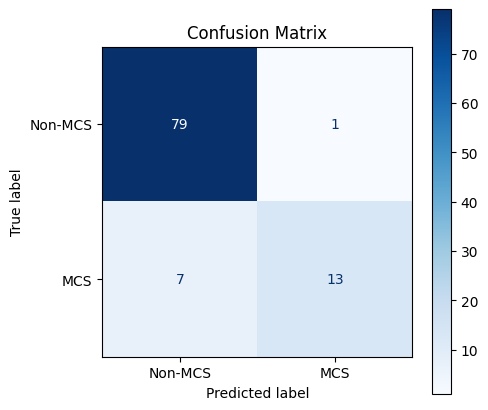

In [58]:
plt.rcParams['figure.figsize'] = 5, 5

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
        rf,
        x_test,
        y_test,
        display_labels=['Non-MCS', 'MCS'],
        cmap=plt.cm.Blues,
        normalize=None,
    )
disp.ax_.set_title("Confusion Matrix")

plt.show()

6. If there are large issues, then do model selection using the training and validation datasets.

- Set up the cross validation approach that selects specific training and validation rows.
- For now, use the same parameters we used with `DecisionTreeClassifier`

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import ParameterGrid

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 2, 4, 6, 8, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}

df_params = pd.DataFrame(list(ParameterGrid(param_grid)))

combined_X = np.concatenate([x_train, x_val])
combined_y = np.concatenate([y_train, y_val])

train_idx = [-1.0] * x_train.shape[0]
val_idx = [0.0] * x_val.shape[0]

splits = np.concatenate([train_idx, val_idx])

from sklearn.model_selection import PredefinedSplit

ps = PredefinedSplit(splits)

for i, (train_index, val_index) in enumerate(ps.split()):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Val:  index={val_index}")

Fold 0:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240

7. Use `GridSearchCV` to find the best random forest model:

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

grid = GridSearchCV(
    estimator=RandomForestClassifier(n_jobs=2, random_state=31826),
    param_grid=param_grid,
    scoring=make_scorer(f1_score, average="binary"),
    cv=ps,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(combined_X, combined_y)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_rf = grid.best_estimator_

y_pred = best_rf.predict(x_test)

sklearn_acc = accuracy_score(y_test, y_pred)
sklearn_pre = precision_score(y_test, y_pred)
sklearn_rec = recall_score(y_test, y_pred)
sklearn_f1 = f1_score(y_test, y_pred)

print(f"Test accuracy is {sklearn_acc:.2f}")
print(f"Test precision is {sklearn_pre:.2f}")
print(f"Test recall is {sklearn_rec:.2f}")
print(f"Test f1 is {sklearn_f1:.2f}")

Fitting 1 folds for each of 192 candidates, totalling 192 fits
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.8421052631578947
Test accuracy is 0.94
Test precision is 0.94
Test recall is 0.75
Test f1 is 0.83


8. Assess the best model.

- **Your Turn**: Did it do better or worse? In what ways?

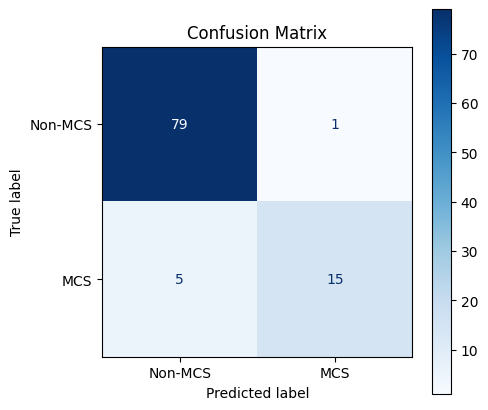

In [61]:
plt.rcParams['figure.figsize'] = 5, 5

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
        best_rf,
        x_test,
        y_test,
        display_labels=['Non-MCS', 'MCS'],
        cmap=plt.cm.Blues,
        normalize=None,
    )
disp.ax_.set_title("Confusion Matrix")

plt.show()

**Try some new parameters used by `RandomForestClassifier`**

The `RandomForestClassfier` has a few extra parameters that might be useful:

1. `n_estimators`: the number of `DecisionTree` models included in the ensemble prediction decision.

2. `bootstrap`: If `True`, provide each tree with a sample (with replacement). This is `True` by default.

3. `n_jobs`: On a multi-core system, you can train individual `DecisionTreeClassifier` models in parallel. Colab provides 2 cpus, so this number can be 1 or 2. If you are on a different system, you can increase this number.

4. `class_weight`: If you are experiencing cases where a rare label is not handled well, you can use `balanced_subsample` to make sure that each bootstrap sample weights certain samples in a way that rewards getting the rare label correct.

Let's see if modifying `n_estimators` helps with the performance. I placed `n_jobs=2` in the constructor call because that should not influence the model performance, just how fast the model finishes training.

If you used all of the parameters, this one might take awhile, since we are testing over 700 different configurations. Additionally, adding more estimators with `n_estimators` will make the configurations with 1000 estimators take longer to train.

In [62]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 2, 4, 6, 8, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "n_estimators": [10, 100],
}

df_params = pd.DataFrame(list(ParameterGrid(param_grid)))

combined_X = np.concatenate([x_train, x_val])
combined_y = np.concatenate([y_train, y_val])

train_idx = [-1.0] * x_train.shape[0]
val_idx = [0.0] * x_val.shape[0]

splits = np.concatenate([train_idx, val_idx])

from sklearn.model_selection import PredefinedSplit

ps = PredefinedSplit(splits)

grid = GridSearchCV(
    estimator=RandomForestClassifier(n_jobs=2, random_state=31826),
    param_grid=param_grid,
    scoring=make_scorer(f1_score, average="binary"),
    cv=ps,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(combined_X, combined_y)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_rf = grid.best_estimator_

y_pred = best_rf.predict(x_test)

sklearn_acc = accuracy_score(y_test, y_pred)
sklearn_pre = precision_score(y_test, y_pred)
sklearn_rec = recall_score(y_test, y_pred)
sklearn_f1 = f1_score(y_test, y_pred)

print(f"Test accuracy is {sklearn_acc:.2f}")
print(f"Test precision is {sklearn_pre:.2f}")
print(f"Test recall is {sklearn_rec:.2f}")
print(f"Test f1 is {sklearn_f1:.2f}")

Fitting 1 folds for each of 384 candidates, totalling 384 fits
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 10}
Best CV F1: 0.8571428571428571
Test accuracy is 0.92
Test precision is 0.93
Test recall is 0.65
Test f1 is 0.76


**We will explore Random Forest models more in Lab 8**